In [2]:
# ============================================================================
# NYC YELLOW TAXI EDA — COMPLETE REFINED CODE
# Dataset: January 2025 Yellow Taxi Trip Records (3.47M trips)
# Project: Predicting Trip Duration & Congestion Fee Exposure
# ============================================================================

In [3]:
# ============================================================================
# STEP 1: LOAD DATA & CHECK STRUCTURE
# Goal: Open the data and understand what you're working with
# ============================================================================

# --- 1a. Import Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# --- 1b. Display Settings (show all columns, clean formatting) ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [5]:
# --- 1c. Load Data ---
file_path = r"C:\Users\hunda\OneDrive\Desktop\Machine Learning Project\raw\yellow_tripdata_2025-01.parquet"
df = pd.read_parquet(file_path)


In [6]:
# --- 1d. Check Size (rows, columns) ---
# Output: (3475226, 20) → 3.47M trips, 20 features
df.shape



(3475226, 20)

In [7]:
# --- 1e. See Column Names ---
for i in df.columns:
    print(f"{i}")

VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
RatecodeID
store_and_fwd_flag
PULocationID
DOLocationID
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount
congestion_surcharge
Airport_fee
cbd_congestion_fee


In [8]:
# --- 1d. Check Size (rows, columns) ---
# Output: (3475226, 20) → 3.47M trips, 20 features
df.shape

(3475226, 20)

In [9]:
# --- 1e. See Column Names ---
for i in df.columns:
    print(f"{i}")

VendorID
tpep_pickup_datetime
tpep_dropoff_datetime
passenger_count
trip_distance
RatecodeID
store_and_fwd_flag
PULocationID
DOLocationID
payment_type
fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount
congestion_surcharge
Airport_fee
cbd_congestion_fee


In [10]:
# --- 1f. Check Data Types & Structure ---
# Look for: data types (int, float, datetime, object), memory usage
# Clue: passenger_count shows float64 instead of int → suggests missing values (NaN forces float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [11]:
# --- 1g. Preview First 5 Rows ---
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.00,1.60,1.00,N,229,237,1,10.00,3.50,0.50,3.00,0.00,1.00,18.00,2.50,0.00,0.00
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.00,0.50,1.00,N,236,237,1,5.10,3.50,0.50,2.02,0.00,1.00,12.12,2.50,0.00,0.00
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.00,0.60,1.00,N,141,141,1,5.10,3.50,0.50,2.00,0.00,1.00,12.10,2.50,0.00,0.00
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.00,0.52,1.00,N,244,244,2,7.20,1.00,0.50,0.00,0.00,1.00,9.70,0.00,0.00,0.00
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.00,0.66,1.00,N,244,116,2,5.80,1.00,0.50,0.00,0.00,1.00,8.30,0.00,0.00,0.00


In [12]:
# ============================================================================
# STEP 2: CHECK DATA QUALITY (MISSING VALUES)
# Goal: Find missing data, how much, and WHY
# ============================================================================

# --- 2a. Statistical Summary (check 'count' row for missing values) ---
# If count < 3,475,226 → that column has missing values
# Finding: 4 columns have count = 2,935,077 → 540,149 missing (15.5%)
# Columns: passenger_count, RatecodeID, congestion_surcharge, Airport_fee
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3475226.00,3475226,3475226,2935077.00,3475226.00,2935077.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,2935077.00,2935077.00,3475226.00
mean,1.79,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.30,5.86,2.48,165.19,164.13,1.04,17.08,1.32,0.48,2.96,0.45,0.95,25.61,2.23,0.12,0.48
min,1.00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.00,0.00,1.00,1.00,1.00,0.00,-900.00,-7.50,-0.50,-86.00,-126.94,-1.00,-901.00,-2.50,-1.75,-0.75
25%,2.00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.00,0.98,1.00,132.00,113.00,1.00,8.60,0.00,0.50,0.00,0.00,1.00,15.20,2.50,0.00,0.00
50%,2.00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.00,1.67,1.00,162.00,162.00,1.00,12.11,0.00,0.50,2.45,0.00,1.00,19.95,2.50,0.00,0.75
75%,2.00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.00,3.10,1.00,234.00,234.00,1.00,19.50,2.50,0.50,3.93,0.00,1.00,27.78,2.50,0.00,0.75
max,7.00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.00,276423.57,99.00,265.00,265.00,5.00,863372.12,15.00,10.50,400.00,170.94,1.00,863380.37,2.50,6.75,0.75
std,0.43,NaN,NaN,0.75,564.60,11.63,64.53,69.40,0.70,463.47,1.86,0.14,3.78,2.00,0.28,463.66,0.90,0.47,0.36


In [13]:
# --- 2b. Check Total Trips Per Vendor ---
# Finding: Vendor 2 dominates (2.7M trips), Vendors 6 & 7 are tiny
df['VendorID'].value_counts()

VendorID
2    2719860
1     753671
7       1206
6        489
Name: count, dtype: int64

In [14]:
# --- 2c. Investigate: Which Vendors Have Missing Data? ---
# Logic: Filter to rows where passenger_count is null → check their VendorID
# Finding: Vendor 2: 451,456 missing (83.6% of all missing)
#          Vendor 1: 88,204 missing
#          Vendor 6: 489 missing (100% of their trips!)
#          Vendor 7: 0 missing (cleanest vendor)
# Conclusion: Missing data is NOT random — it's systematic vendor data collection issue
df[df['passenger_count'].isnull()]['VendorID'].value_counts()

VendorID
2    451456
1     88204
6       489
Name: count, dtype: int64

In [15]:
# ============================================================================
# STEP 3: STATISTICAL SUMMARY & SUSPICIOUS VALUES
# Goal: Check if numbers make sense in real life, quantify problems
# ============================================================================

# --- 3a. Review describe() output for suspicious values ---
# Check MIN values: zeros/negatives that shouldn't exist
# Check MAX values: impossibly large values
# Check MEAN vs MEDIAN (50%): big gap = skewed data with outliers
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3475226.00,3475226,3475226,2935077.00,3475226.00,2935077.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,3475226.00,2935077.00,2935077.00,3475226.00
mean,1.79,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.30,5.86,2.48,165.19,164.13,1.04,17.08,1.32,0.48,2.96,0.45,0.95,25.61,2.23,0.12,0.48
min,1.00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.00,0.00,1.00,1.00,1.00,0.00,-900.00,-7.50,-0.50,-86.00,-126.94,-1.00,-901.00,-2.50,-1.75,-0.75
25%,2.00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.00,0.98,1.00,132.00,113.00,1.00,8.60,0.00,0.50,0.00,0.00,1.00,15.20,2.50,0.00,0.00
50%,2.00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.00,1.67,1.00,162.00,162.00,1.00,12.11,0.00,0.50,2.45,0.00,1.00,19.95,2.50,0.00,0.75
75%,2.00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.00,3.10,1.00,234.00,234.00,1.00,19.50,2.50,0.50,3.93,0.00,1.00,27.78,2.50,0.00,0.75
max,7.00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.00,276423.57,99.00,265.00,265.00,5.00,863372.12,15.00,10.50,400.00,170.94,1.00,863380.37,2.50,6.75,0.75
std,0.43,NaN,NaN,0.75,564.60,11.63,64.53,69.40,0.70,463.47,1.86,0.14,3.78,2.00,0.28,463.66,0.90,0.47,0.36


In [16]:
# --- 3b. Quantify: Zero Passengers ---
# Finding: 24,656 trips (0.7%) — data entry error, can't have trip with no one
df[df['passenger_count'] == 0].shape[0]

24656

In [17]:
# --- 3c. Quantify: Zero Distance ---
# Finding: 90,893 trips (2.6%) — cancelled trips or meter errors
df[df['trip_distance'] == 0].shape[0]

90893

In [18]:
# --- 3d. Quantify: Negative Fares ---
# Finding: 144,118 trips (4.1%) — likely refunds/adjustments, not real trips
df[df['fare_amount'] < 0].shape[0]

144118

In [19]:
# --- 3e. Quantify: Extreme Fares (> $1,000) ---
# Finding: Only 3 trips — clearly data errors, easy to remove
df[df['fare_amount'] > 1000].shape[0]

3

In [20]:
# --- 3f. Quantify: Extreme Distance (> 100 miles) ---
# Finding: Only 162 trips — data errors (max is 276,423 miles = 11x around Earth!)
df[df['trip_distance'] > 100].shape[0]

162

In [21]:
# --- 3g. Quantify: Pre-Congestion Pricing Trips (before Jan 5, 2025) ---
# Finding: 364,095 trips (10.5%)
# Note: Valid for Model 1 (duration), INVALID for Model 2 (fee didn't exist yet)
df[df['tpep_pickup_datetime'] < '2025-01-05'].shape[0]

364095

In [22]:
# --- 3h. Quantify: Dropoff Before Pickup (physically impossible) ---
# Finding: 124 trips — data errors
len(df[(df['tpep_dropoff_datetime']) < (df['tpep_pickup_datetime'])])

124

In [23]:
# --- 3i. Quantify: RatecodeID = 99 (null/unknown) ---
# Finding: 41,963 trips — invalid rate code
(df['RatecodeID'] == 99).sum()

41963

In [24]:
# --- 3j. Check Payment Type Distribution ---
# Finding: Type 1 (credit card) dominates
#          Types 3 (no charge): 23,773, Type 4 (dispute): 76,481, Type 5 (unknown): 1
#          Total non-standard: 100,255 — consider removing
df['payment_type'].value_counts()

payment_type
1    2444393
0     540149
2     390429
4      76481
3      23773
5          1
Name: count, dtype: int64

In [25]:
# --- 3k. Check RatecodeID Distribution ---
df['RatecodeID'].value_counts()

RatecodeID
1.00     2756472
2.00       94420
99.00      41963
5.00       26501
3.00        8622
4.00        7092
6.00           7
Name: count, dtype: int64

In [26]:
# ============================================================================
# STEP 4: EXPLORE DISTRIBUTIONS (VISUALIZATIONS)
# Goal: SEE the shape of data — patterns, clusters, anomalies
# Chart selection: Continuous data → histplot | Categorical → countplot
# ============================================================================

# --- 4a. Create Temporal Features for Visualization ---
# trip_duration: dropoff - pickup in minutes (Model 1 target)
# pickup_hour: hour of day (0-23) extracted from pickup time
# pickup_day: day name (Monday, Tuesday...) extracted from pickup time
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

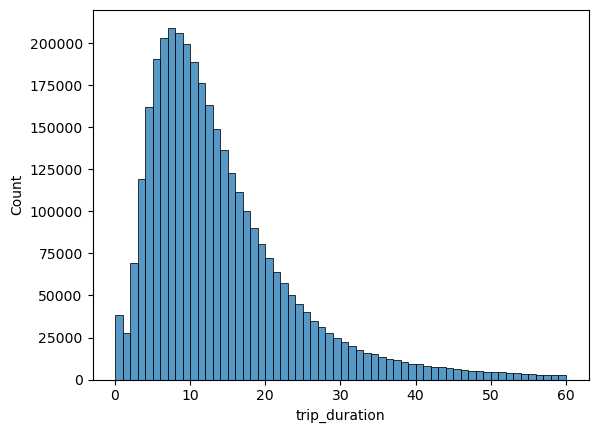

In [27]:
# --- 4b. VIS 1: Trip Duration Distribution (Model 1 Target) ---
# Why: Must understand the shape of what you're predicting
# Finding: Peak at 7-10 min, right-skewed, matches real NYC experience
# Filter: 0-60 min only (removes negatives and extreme outliers)
# bins=60: each bin ≈ 1 minute for easy reading
sns.histplot(df[(df['trip_duration'] > 0) & (df['trip_duration'] <= 60)]['trip_duration'], bins=60)
plt.show()

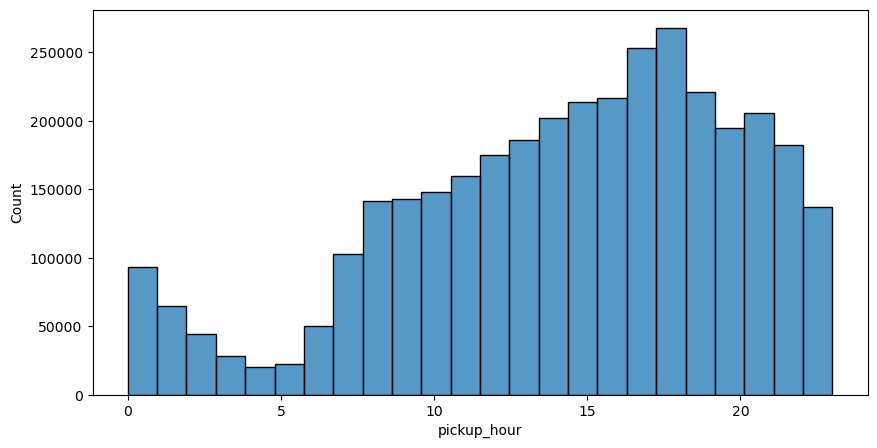

In [28]:
# --- 4c. VIS 2: Pickup Hour Distribution ---
# Why: Time-of-day affects traffic (rush hour) and fee eligibility
# Finding: Peak 5-6 PM (rush hour), lowest 2-5 AM
# bins=24: one bin per hour
plt.figure(figsize=(10, 5))
sns.histplot(x='pickup_hour', data=df, bins=24)
plt.show()

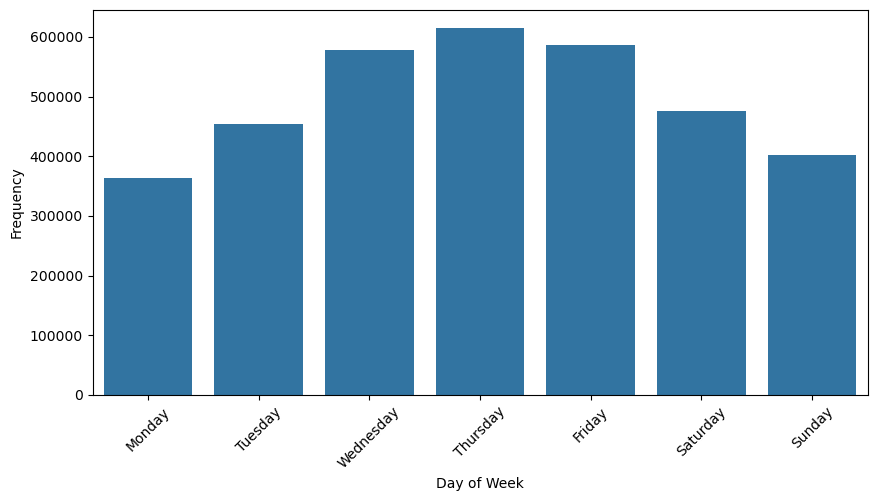

pickup_day
Thursday     614230
Friday       586863
Wednesday    577375
Saturday     476399
Tuesday      453993
Sunday       402594
Monday       363772
Name: count, dtype: int64

In [29]:
# --- 4d. VIS 3: Pickup Day of Week Distribution ---
# Why: Weekday vs weekend affects traffic patterns and fee hours
# Finding: Thu > Fri > Wed busiest. Mon & Sun quietest.
# order=day_order: forces Monday→Sunday order (not alphabetical)
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='pickup_day', data=df, order=day_order)
plt.xlabel("Day of Week")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()

df['pickup_day'].value_counts()

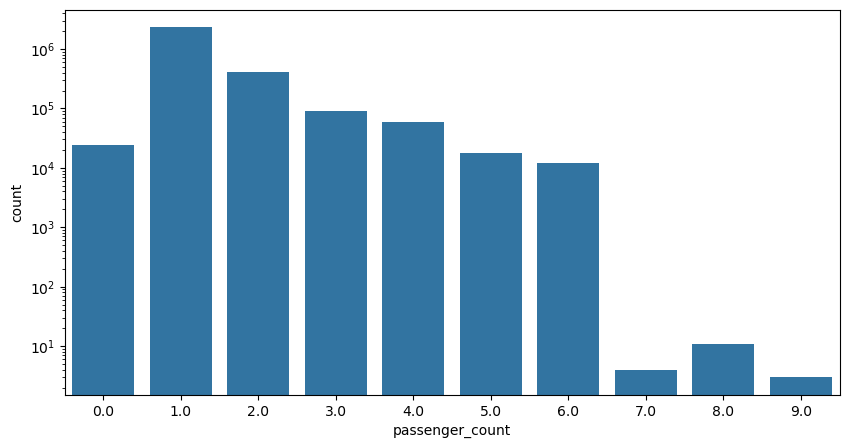

passenger_count
1.00    2322434
2.00     407761
3.00      91409
4.00      59009
0.00      24656
5.00      17786
6.00      12004
8.00         11
7.00          4
9.00          3
Name: count, dtype: int64

In [30]:
# --- 4e. VIS 4: Passenger Count Distribution ---
# Why: Understand rider patterns and spot data errors (0 and 7-9 passengers)
# Finding: 67% solo riders. Errors: 0 passengers (24,656), 7-9 passengers (18)
# Log scale: makes tiny categories (7,8,9) visible next to 2.3M for count=1
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='passenger_count', data=df)
ax.set_yscale("log")
plt.show()

df['passenger_count'].value_counts()

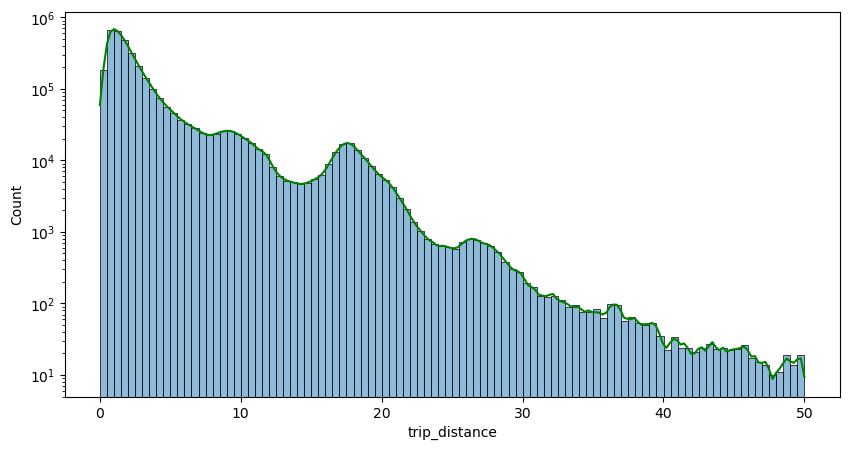

In [31]:
# --- 4f. VIS 5: Trip Distance Distribution ---
# Why: Strongest predictor for duration model — must understand its shape
# Finding: Peak 0-5 miles, heavily right-skewed, JFK bump at 17-18 miles
# Filter: 0-50 miles (removes 0 distance and 276K mile outliers)
# kde=True: adds smooth curve showing distribution shape
# Log scale: reveals the long tail of longer trips
plt.figure(figsize=(10, 5))
filtered_distance = df[(df['trip_distance'] > 0) & (df['trip_distance'] <= 50)]['trip_distance']
ax = sns.histplot(x=filtered_distance, bins=100, kde=True, line_kws={'color': 'green'})
ax.set_yscale("log")
ax.lines[0].set_color('green')
plt.show()

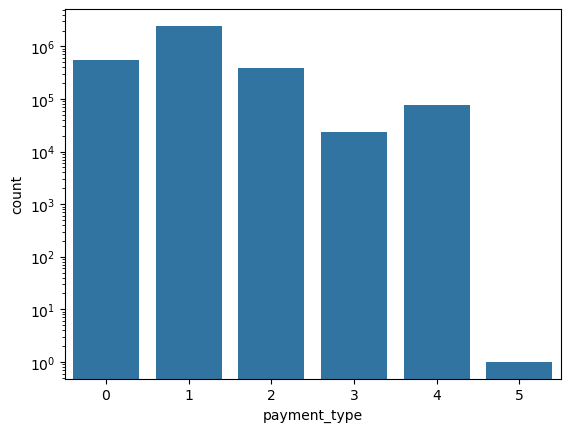

payment_type
1    2444393
0     540149
2     390429
4      76481
3      23773
5          1
Name: count, dtype: int64

In [32]:
# --- 4g. VIS 6: Payment Type Distribution ---
# Why: Affects tip data quality (tips only recorded for credit card payments)
# Finding: Credit card (type 1) dominant. Cash (type 2) second.
# Types 3,4,5 are rare non-standard transactions.
ax = sns.countplot(x='payment_type', data=df)
ax.set_yscale('log')
plt.show()

df['payment_type'].value_counts()

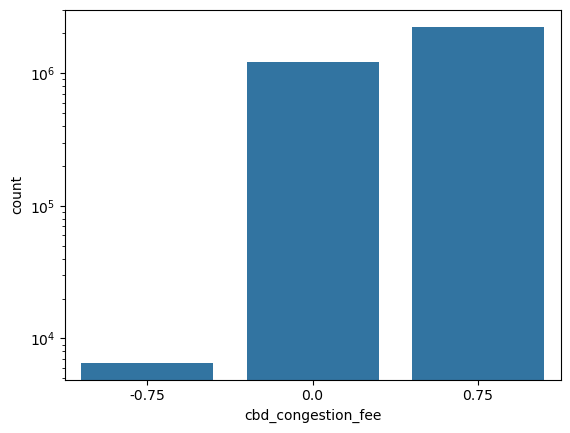

cbd_congestion_fee
0.75     2246495
0.00     1222178
-0.75       6553
Name: count, dtype: int64

In [33]:
# --- 4h. VIS 7: CBD Congestion Fee Distribution (Model 2 Target) ---
# Why: MUST check class balance for classification model
# Finding: 64.6% charged ($0.75), 35.2% not charged ($0.00), 0.2% refunds (-$0.75)
# Class balance: 65/35 — healthy, not dangerously imbalanced
ax = sns.countplot(x='cbd_congestion_fee', data=df)
ax.set_yscale('log')
plt.show()

df['cbd_congestion_fee'].value_counts()

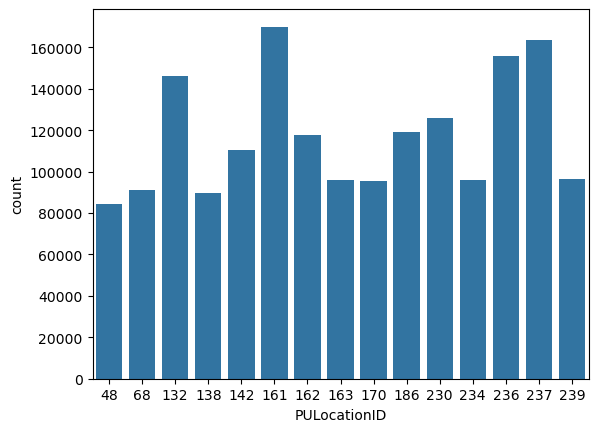

PULocationID
161    169977
237    163703
236    155647
132    146137
230    125829
186    119131
162    117930
142    110585
239     96614
163     95906
234     95896
170     95636
68      91241
138     89658
48      84137
Name: count, dtype: int64

In [34]:
# --- 4i. VIS 8: Top 15 Pickup Locations ---
# Why: Pickup location determines congestion zone entry (strongest feature for Model 2)
# Finding: Zone 161 (Midtown) busiest. Most top zones are Manhattan.
#          Airports (132=JFK, 138=LaGuardia) in top 15.
# .isin() pattern: plot only top 15 out of 265 zones for readability
top_15_pu = df['PULocationID'].value_counts().head(15).index
sns.countplot(x='PULocationID', data=df[df['PULocationID'].isin(top_15_pu)])
plt.show()

df['PULocationID'].value_counts().head(15)

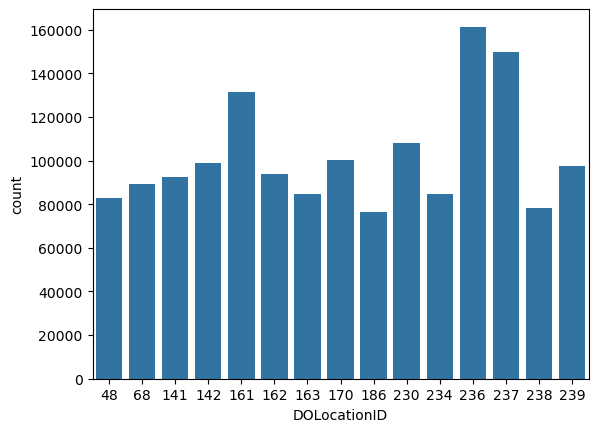

In [35]:
# --- 4j. VIS 9: Top 15 Dropoff Locations ---
# Why: Trips TO CBD also get charged even if starting outside
# Finding: Similar zones as pickups. Airports absent from top dropoffs.
top_15_do = df['DOLocationID'].value_counts().head(15).index
sns.countplot(x='DOLocationID', data=df[df['DOLocationID'].isin(top_15_do)])
plt.show()

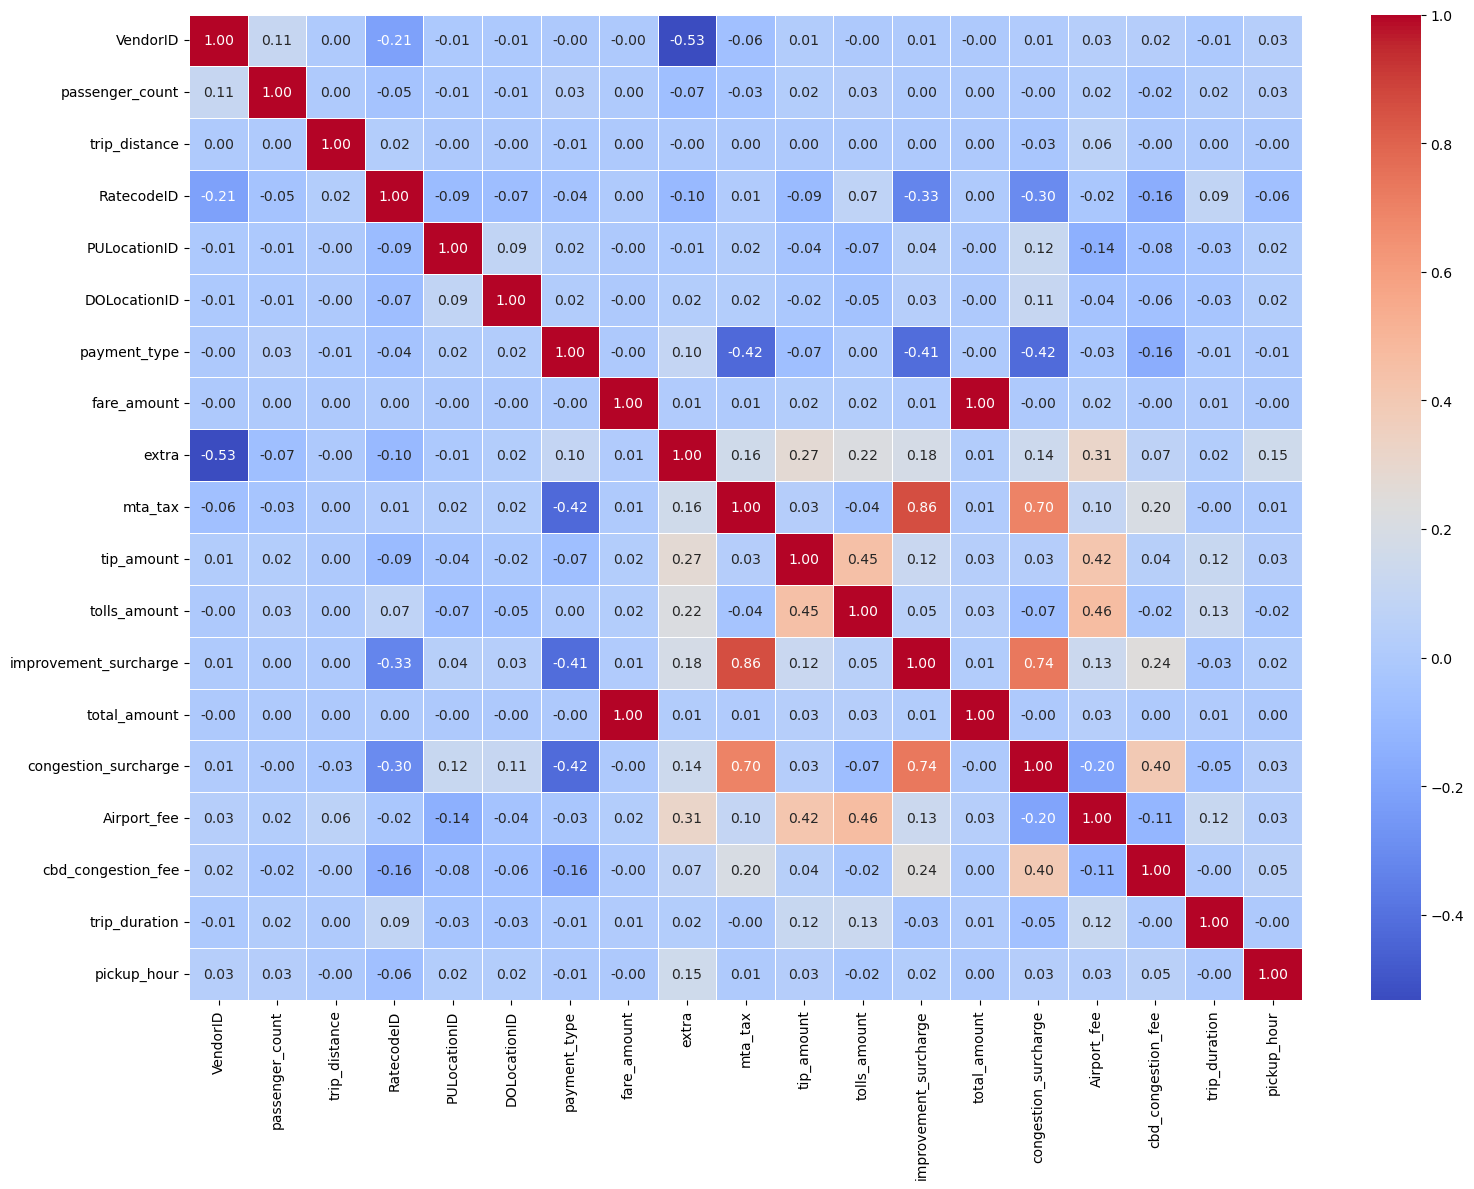

In [36]:
# ============================================================================
# STEP 5: EXPLORE RELATIONSHIPS
# Goal: How do columns relate to EACH OTHER?
# Step 4 = one column at a time | Step 5 = two+ columns together
# ============================================================================

# --- 5a. Correlation Heatmap ---
# Shows relationship strength between ALL numeric columns at once
# WARNING: Correlation on uncleaned data is UNRELIABLE — outliers distort values
# Finding: trip_distance vs trip_duration shows 0.00 (should be high!)
#          This is because 276K mile trips and negative durations confuse the math.
#          Re-run AFTER data cleaning for accurate results.
# mta_tax & improvement_surcharge: 0.86 correlation — but both nearly constant ($0.50, $1.00)
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.tight_layout()
plt.show()

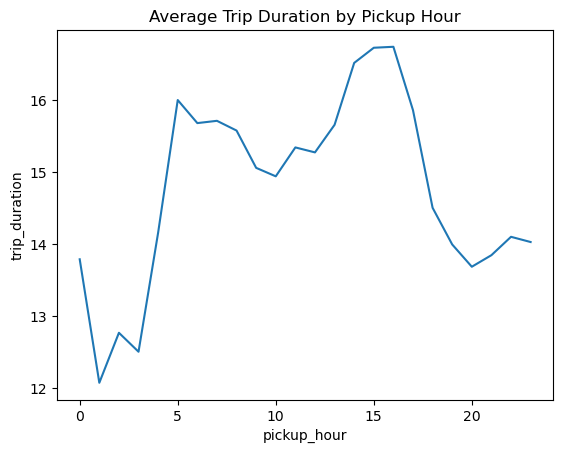

In [37]:
# --- 5b. Average Trip Duration by Pickup Hour (Grouped Analysis) ---
# Why: Does trip duration change based on time of day?
# Logic: Group all trips by hour → calculate average duration per hour
# Finding: Fastest at 1 AM (~12 min), slowest at 3-4 PM (~17 min) — 40% difference!
# This PROVES pickup_hour affects duration even though correlation showed 0.00
# Lesson: Grouped analysis catches non-linear relationships that correlation misses
sns.lineplot(df.groupby(df['pickup_hour'])['trip_duration'].mean())
plt.xlabel('pickup_hour')
plt.ylabel('trip_duration')
plt.title('Average Trip Duration by Pickup Hour')
plt.show()

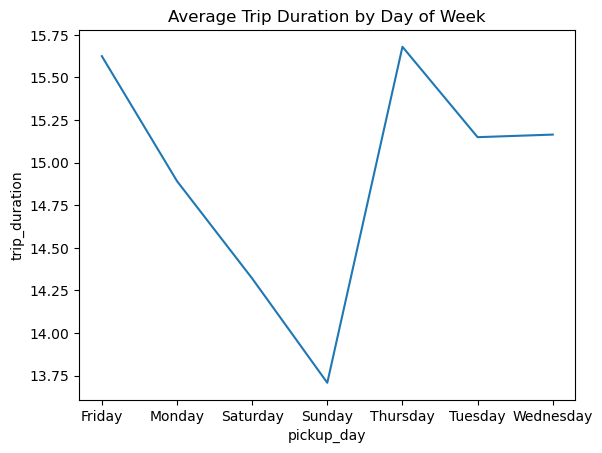

In [38]:
# --- 5c. Average Trip Duration by Pickup Day (Grouped Analysis) ---
# Why: Do trips take longer on certain days?
# Finding: Weekdays (~15-15.7 min) longer than weekends (~13.7-14.3 min)
#          Thu/Fri longest, Sun shortest
# Reason: Weekday rush hour traffic vs lighter weekend traffic
sns.lineplot(df.groupby(df['pickup_day'])['trip_duration'].mean())
plt.xlabel('pickup_day')
plt.ylabel('trip_duration')
plt.title('Average Trip Duration by Day of Week')
plt.show()

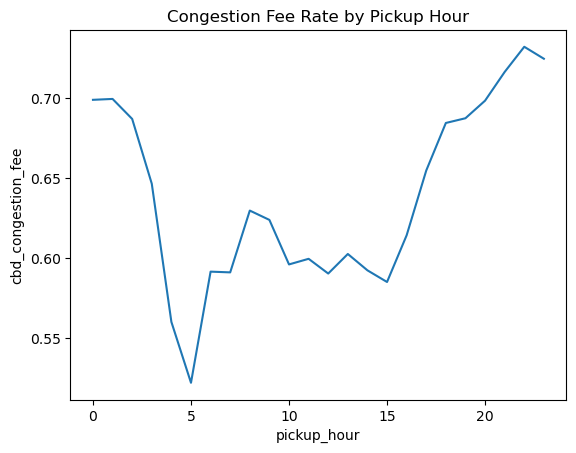

In [39]:
# --- 5d. Congestion Fee Rate by Pickup Hour ---
# Why: At which hours are trips most likely to be charged the fee?
# Technique: Mean of True/False = Percentage
#   (df['cbd_congestion_fee'] == 0.75) creates True(1)/False(0)
#   .groupby(hour).mean() gives percentage of Trues per hour
# SURPRISE Finding: Late night (0-2 AM) has HIGHEST fee rate (~70-73%)
#   even though fee isn't active at night!
#   Reason: Late night trips concentrate in Manhattan (nightlife) = inside CBD zone
#   Conclusion: LOCATION matters more than TIME for congestion fee prediction
fee_by_hour = (df['cbd_congestion_fee'] == 0.75).groupby(df['pickup_hour']).mean()
sns.lineplot(fee_by_hour)
plt.xlabel('pickup_hour')
plt.ylabel('cbd_congestion_fee')
plt.title('Congestion Fee Rate by Pickup Hour')
plt.show()

In [40]:
# --- 5e. Congestion Fee Rate by Top 15 Pickup Locations ---
# Why: Which zones have highest congestion fee exposure?
# Finding: Manhattan zones (234, 162, 161): 80-90% fee rate
#          LaGuardia (138): ~44% (close to Manhattan)
#          JFK (132): ~30% (far from Manhattan)
#          Geography directly explains the difference!

# Step 1: Get top 15 pickup zones
top_15_pu = df['PULocationID'].value_counts().head(15).index

In [41]:
# Step 2: Filter to only those zones
filtered = df[df['PULocationID'].isin(top_15_pu)]

In [42]:
# Step 3: Calculate fee rate for each zone
fee_by_location = (filtered['cbd_congestion_fee'] == 0.75).groupby(filtered['PULocationID']).mean()

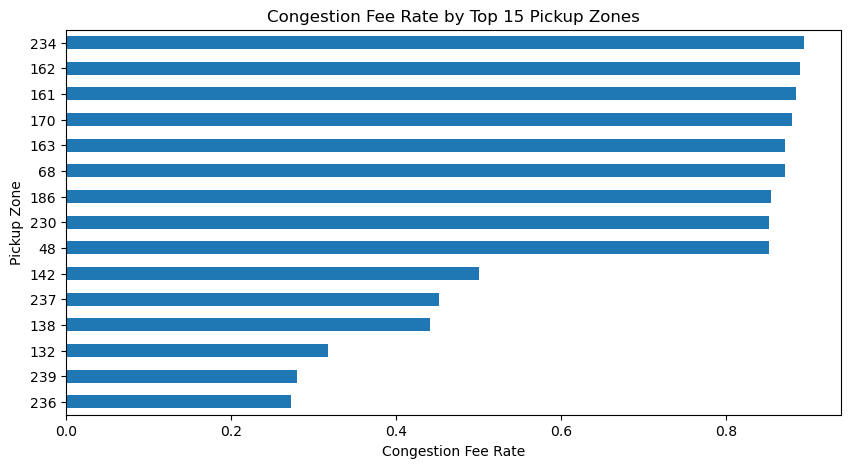

In [43]:
# Step 4: Plot sorted horizontal bars
plt.figure(figsize=(10, 5))
fee_by_location.sort_values().plot(kind='barh')
plt.xlabel('Congestion Fee Rate')
plt.ylabel('Pickup Zone')
plt.title('Congestion Fee Rate by Top 15 Pickup Zones')
plt.show()

In [44]:
# ============================================================================
# EDA COMPLETE — SUMMARY OF FINDINGS
# ============================================================================
# Dataset: 3,475,226 trips × 20 columns (January 2025)
#
# DATA QUALITY ISSUES FOUND:
#   - Missing values: 540,149 rows in 4 columns (15.5%) — vendor-related
#   - Zero passengers: 24,656 (0.7%)
#   - Zero distance: 90,893 (2.6%)
#   - Negative fares: 144,118 (4.1%) — likely refunds
#   - Pre-Jan-5 trips: 364,095 (10.5%) — valid for Model 1, invalid for Model 2
#   - RatecodeID = 99: 41,963 (1.2%)
#   - Non-standard payments (3,4,5): 100,255
#   - Dropoff before pickup: 124
#   - Extreme distance >100mi: 162
#   - Extreme fare >$1000: 3
#   - Passenger count 7-9: 18
#   - CBD fee refunds (-$0.75): 6,553
#
# KEY INSIGHTS:
#   - Typical trip: 1 passenger, 1-3 miles, 7-10 minutes, $15-$28 total
#   - 64.6% of trips charged congestion fee — healthy class balance
#   - Location > Time for congestion fee prediction
#   - Correlation unreliable on uncleaned data — must re-run after cleaning
#   - Rush hour (5-6 PM) = most trips AND longest durations
#   - Thursday/Friday busiest days
#
# NEXT STEP: Data Cleaning → then Feature Engineering → Model Building
# ============================================================================